# Kerr Sign and Frame Checks


This notebook rewrites `examples/kerr_sign_verification.py` as a validation notebook. Its purpose is not to introduce the API from scratch, but to confirm that the runtime Kerr sign used by `cqed_sim` matches the documented convention once the frame choice and observable phase are interpreted correctly.

This kind of notebook belongs in a validation / conventions track because its primary question is correctness of interpretation, not everyday workflow onboarding.


## Imports


In [1]:

from pathlib import Path
import sys

REPO_ROOT = next(
    (
        candidate
        for candidate in (Path.cwd(), *Path.cwd().parents)
        if (candidate / "pyproject.toml").exists() and (candidate / "cqed_sim").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Could not resolve the repository root from the notebook working directory.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from tutorials.workflow_tutorial_support import configure_notebook_style

configure_notebook_style()

from cqed_sim import coherent_state
from examples.workflows.kerr_free_evolution import (
    KerrParameterSet,
    resolve_kerr_parameter_set,
    run_kerr_free_evolution,
    times_us_to_seconds,
    verify_kerr_sign,
)

## Physics / model definition


In [2]:
base = resolve_kerr_parameter_set("phase_evolution")
flipped = KerrParameterSet(
    name=f"{base.name}_self_kerr_flipped",
    omega_q_hz=base.omega_q_hz,
    omega_c_hz=base.omega_c_hz,
    omega_ro_hz=base.omega_ro_hz,
    alpha_q_hz=base.alpha_q_hz,
    kerr_hz=-base.kerr_hz,
    kerr2_hz=base.kerr2_hz,
    chi_hz=base.chi_hz,
    chi2_hz=base.chi2_hz,
    chi3_hz=base.chi3_hz,
)
times_us = np.array([0.0, 0.25, 0.50, 0.75, 1.00], dtype=float)


## Pulse / sequence construction


In [3]:
times_s = times_us_to_seconds(times_us)
initial_state = coherent_state(2.0)
print("This validation notebook uses free evolution only; the sign check comes from the static Hamiltonian, not from a driven pulse.")


This validation notebook uses free evolution only; the sign check comes from the static Hamiltonian, not from a driven pulse.


## Simulation


In [4]:
documented = run_kerr_free_evolution(
    times_s,
    parameter_set=base,
    cavity_state=initial_state,
    n_cav=30,
    wigner_times_s=[],
)
flipped_result = run_kerr_free_evolution(
    times_s,
    parameter_set=flipped,
    cavity_state=initial_state,
    n_cav=30,
    wigner_times_s=[],
)
sign_check = verify_kerr_sign(comparison_time_s=1.0e-6, alpha=2.0, n_cav=30, n_tr=3)

documented_phase = np.unwrap(
    np.angle(np.asarray([snapshot.cavity_mean for snapshot in documented.snapshots], dtype=np.complex128))
)
flipped_phase = np.unwrap(
    np.angle(np.asarray([snapshot.cavity_mean for snapshot in flipped_result.snapshots], dtype=np.complex128))
)

print("Documented Kerr [Hz]:", sign_check.documented_kerr_hz)
print("Flipped Kerr [Hz]:", sign_check.flipped_kerr_hz)
print("Matches documented sign:", sign_check.matches_documented_sign)


Documented Kerr [Hz]: -107900.0
Flipped Kerr [Hz]: 107900.0
Matches documented sign: True


## Analysis / visualization


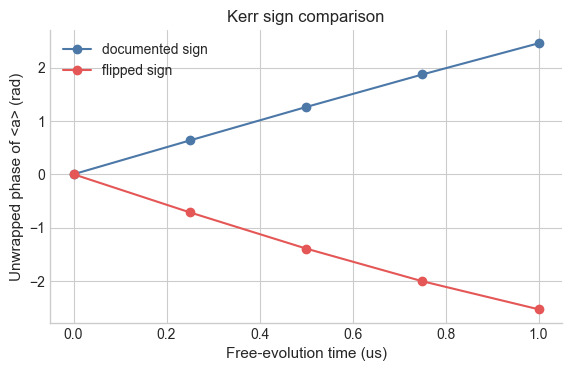

In [5]:
fig, ax = plt.subplots(figsize=(6.6, 3.8))
ax.plot(times_us, documented_phase, "o-", label="documented sign", color="#4C78A8")
ax.plot(times_us, flipped_phase, "o-", label="flipped sign", color="#E45756")
ax.set_xlabel("Free-evolution time (us)")
ax.set_ylabel("Unwrapped phase of <a> (rad)")
ax.set_title("Kerr sign comparison")
ax.legend(loc="best")
plt.show()


## Interpretation


The two curves bend in opposite directions, and the documented-sign result matches the repository's runtime convention. If you ever think the sign has flipped, check the rotating frame and the plotted observable before changing the Hamiltonian.

This notebook complements the workflow tutorial on Kerr free evolution: that notebook teaches the phenomenon, while this notebook verifies that the implementation and interpretation remain aligned with the documented convention.


## Variations / exercises


- Repeat the check in a lab-frame calculation to separate frame offsets from Kerr-induced curvature.
- Compare the sign of the mean-field phase with the sign of the Wigner-function shear.
- Pair this notebook with `tests/test_32_kerr_sign_notebook_regression.py` when you need an automated guardrail.
